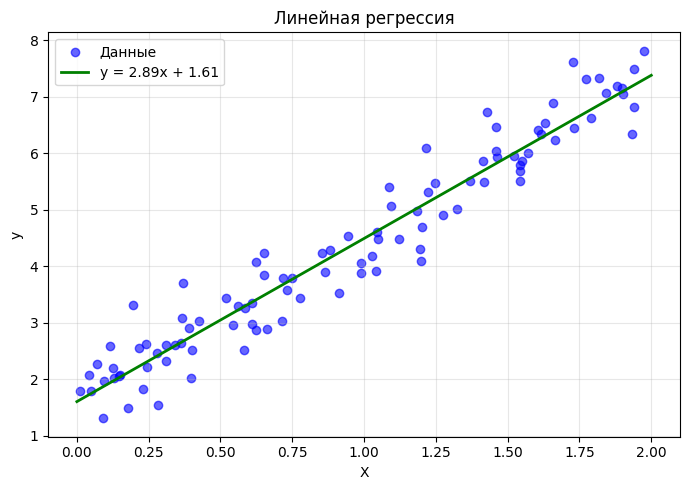

In [37]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(100)
y = 3 * X + 1.5 + np.random.randn(100) * 0.5

def compute_predictions(X, w, b):
    return X * w + b

def compute_loss(y_pred, y_true):
    n = len(y_true)
    return (1 / n) * np.sum((y_pred - y_true) ** 2)

def compute_gradients(X, y_true, y_pred):
    n = len(y_true)
    dw = (2 / n) * np.sum((y_pred - y_true) * X)
    db = (2 / n) * np.sum(y_pred - y_true)
    return dw, db

def train(X, y, learning_rate=0.1, epochs=1000):
    w = 0.0
    b = 0.0

    for _ in range(epochs):
        y_pred = compute_predictions(X, w, b)
        dw, db = compute_gradients(X, y, y_pred)
        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b

w, b = train(X, y)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, color="blue", alpha=0.6, label="Данные")
X_line = np.linspace(0, 2, 100)
y_line = compute_predictions(X_line, w, b)
plt.plot(X_line, y_line, color="green", linewidth=2, label=f"y = {w:.2f}x + {b:.2f}")
plt.title("Линейная регрессия")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:


def process_car_data(df, is_train=True, encoder=None, mileage_medians=None):
    df = df.copy()
    

    if is_train:
        df = df.dropna()
        df = df[(df['price'] >= 30000) & (df['price'] <= 7000000)]
        names = ['CR-V', 'Accord', 'Camry', 'RAV4', 'X-Trail', 'Teana']
        df = (
            df[df['name'].isin(names)]
            .groupby('name', group_keys=False)
            .apply(lambda x: x.sample(n=min(1700, len(x)), random_state=42)) 
            .reset_index(drop=True)
        )
        
        df = df.dropna(subset=['color', 'description', 'engineName', 'fuelType', 'mileage'])


    df['engineDisplacement'] = df['engineDisplacement'].astype(str).str.extract(r'([\d.]+)').astype(float)
    
    def estimate_displacement(row):
        if pd.isna(row['engineDisplacement']) and pd.notna(row['power']):
            fuel, hp = row['fuelType'], row['power']
            if fuel == 'Электро': return round(hp / 65, 1)
            elif fuel == 'Дизель': return round(hp / 70, 1)
            else: return round(hp / 60, 1)
        return row['engineDisplacement']
        
    df['engineDisplacement'] = df.apply(estimate_displacement, axis=1)

    df['year'] = df['year'].astype(int)
    
    if is_train:
        mileage_medians = df.groupby('year')['mileage'].median()
        
    mask = df['mileage'].isna()
    df.loc[mask, 'mileage'] = df.loc[mask, 'year'].map(mileage_medians)
    df['mileage'] = df['mileage'].fillna(df['mileage'].median())


    df['date'] = pd.to_datetime(df['date'])
    df['years_in_service'] = df['date'].max().year - df['year']
    
    df['mileage_per_year'] = (df['mileage'] / df['years_in_service'].replace(0, 1)).round(0)
    df['power_per_liter'] = (df['power'] / df['engineDisplacement']).round(1)

    
    pos_words = ['хорошее состояние', 'отличное', 'идеальное', 'не гнилой', 'гнили нет', 'без гнили', 'замена', 'новое', 'новый', 'капиталки', 'капремонт', 'грм', 'помпа', 'сцепление', 'колодки', 'стойки', 'резина', 'один владелец']
    neg_words = ['битый', 'крашеный', 'после дтп', 'не на ходу', 'требует ремонта', 'ржавчина', 'гниль', 'коррозия', 'вмятина', 'царапина', 'троит', 'дымит', 'течет масло', 'стук', 'расход масла', 'без птс', 'утилизация', 'в залоге', 'старый']
    
    def estimate_condition(text):
        if pd.isna(text): return 0.0
        text = str(text).lower()
        score = sum(0.3 for w in pos_words if w in text) - sum(0.4 for w in neg_words if w in text)
        return round(score, 1)
        
    df['condition_score'] = df['description'].apply(estimate_condition)


    cat_cols = ['name', 'brand', 'fuelType', 'bodyType', 'transmission']
    
    # Обучаем энкодер только на Train, на новых данных просто применяем
    if is_train:
        # handle_unknown='ignore', если при прогнозе попадется неизвестная категория
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
        encoded_data = encoder.fit_transform(df[cat_cols].astype(str))
    else:
        encoded_data = encoder.transform(df[cat_cols].astype(str))
        
    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols), index=df.index)
    df = pd.concat([df, encoded_df], axis=1)

  
    cols_to_drop = [
        'link', 'date', 'parse_date', 'description', 'years_in_service', 
        'engineName', 'location', 'color', 'vehicleConfiguration'
    ] + cat_cols 
    
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    return df, encoder, mileage_medians

In [42]:
 
df_raw = pd.read_csv('all_regions.csv')
df, my_encoder,my_medians  = process_car_data(df_raw, is_train=True)
X = df.drop('price', axis=1)
y = df['price']

C:\Users\igor\AppData\Local\Temp\ipykernel_19404\962563294.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(1700, len(x)), random_state=42))


Эксперимент  1 


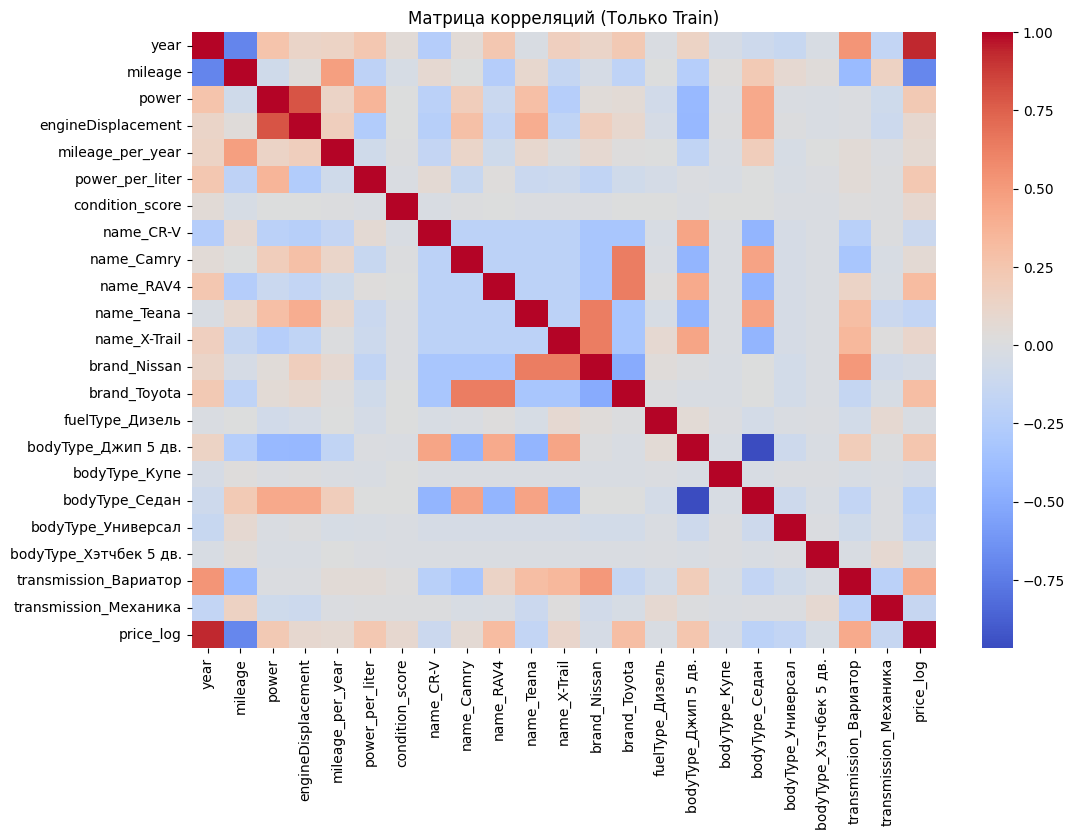

LinearRegression()

In [ ]:
print("Эксперимент  1 ")

# 1. Применяем стандартизацию 
scaler_exp1 = StandardScaler()
X_scaled_all = scaler_exp1.fit_transform(X) # fit (нашли среднее) и transform (применили) для всех
X_scaled_all = pd.DataFrame(X_scaled_all, columns=X.columns)

# 2. цены скошены, логарифм делает распределение нормальным)
y_log_all = np.log1p(y) 
plt.figure(figsize=(12, 8))
# Объединяем X_train и y_train_log временно для матрицы
train_for_corr = X_scaled_all.copy()
train_for_corr['price_log'] = y_log_all

sns.heatmap(train_for_corr.corr(), annot=False, cmap='coolwarm')
plt.title("Матрица корреляций")
plt.show()
# 3. Разделение на train и test 
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_scaled_all, y_log_all, test_size=0.2, random_state=42
)

# 4. Обучение модели
model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)

Эксперимент  2


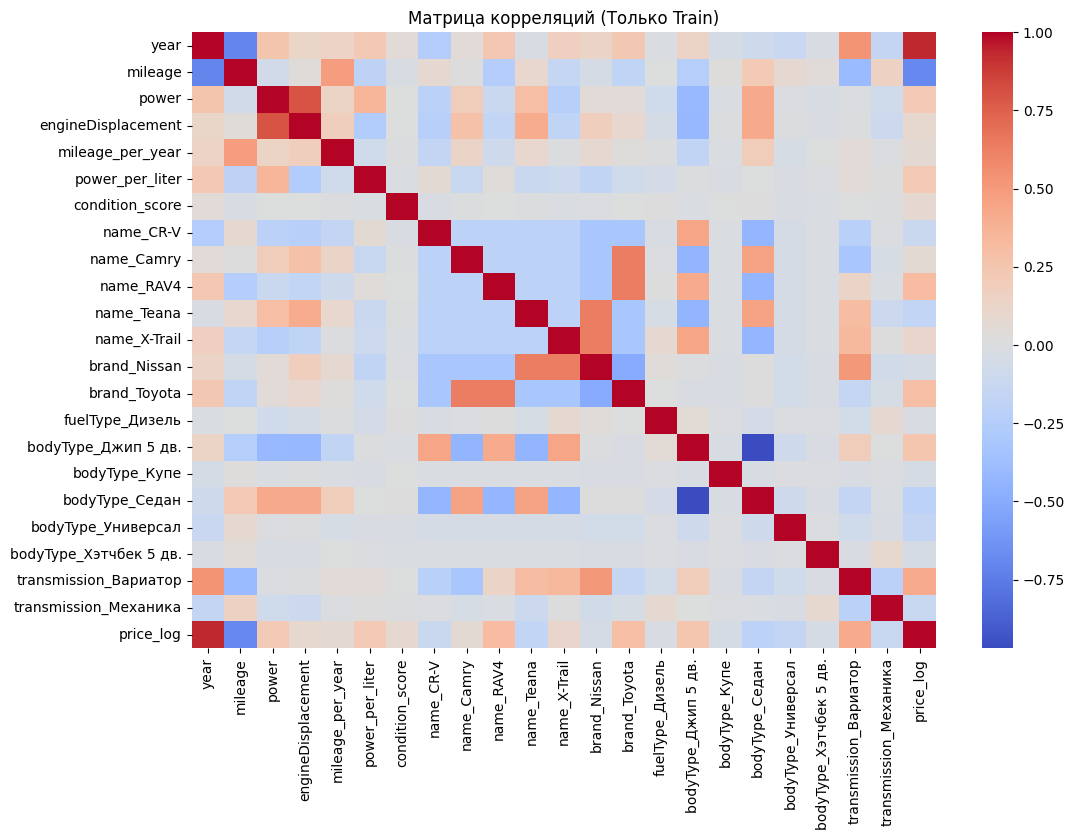

LinearRegression()

In [ ]:
print("Эксперимент  2")

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Логарифмирование таргета 
y_train_log = np.log1p(y_train_2)
y_test_log = np.log1p(y_test_2)

plt.figure(figsize=(12, 8))
# Объединяем X_train и y_train_log временно для матрицы
train_for_corr = X_train_2.copy()
train_for_corr['price_log'] = y_train_log

sns.heatmap(train_for_corr.corr(), annot=False, cmap='coolwarm')
plt.title("Матрица корреляций (Только Train)")
plt.show()



# 3. Стандартизация.  fit ТОЛЬКО на train
scaler_exp2 = StandardScaler()
scaler_exp2.fit(X_train_2) 

# transform и к train, и к test
X_train_scaled_2 = scaler_exp2.transform(X_train_2)
X_test_scaled_2 = scaler_exp2.transform(X_test_2)

X_train_scaled_2 = pd.DataFrame(X_train_scaled_2, columns=X_train_2.columns)
X_test_scaled_2 = pd.DataFrame(X_test_scaled_2, columns=X_test_2.columns)

model_2 = LinearRegression()
model_2.fit(X_train_scaled_2, y_train_log)

In [ ]:
y_pred_log_1 = model_1.predict(X_test_1)

#  экспонента
y_test_real_1 = np.expm1(y_test_1)
y_pred_real_1 = np.expm1(y_pred_log_1)

# Оценка метрик
print("Метрики качества (Эксперимент 1):")
print(f"MAE (Средняя абс. ошибка): {mean_absolute_error(y_test_real_1, y_pred_real_1):,.0f} руб.")
print(f"MSE (Средняя кв. ошибка): {mean_squared_error(y_test_real_1, y_pred_real_1):,.0f}")
print(f"R² (Коэф. детерминации): {r2_score(y_test_real_1, y_pred_real_1):.3f}")

# Анализ важности признаков (Эксперимент 1)
importance_1 = pd.DataFrame({
    'Признак': X_train_1.columns,
    'Вес (Влияние)': model_1.coef_
})

# Сортируем по модулю веса 
importance_1['Модуль_веса'] = importance_1['Вес (Влияние)'].abs()
importance_1 = importance_1.sort_values(by='Модуль_веса', ascending=False)

print("\nТоп-5 самых важных признаков (Эксперимент 1):")
print(importance_1[['Признак', 'Вес (Влияние)']].head())


Метрики качества (Эксперимент 1):
MAE (Средняя абс. ошибка): 149,745 руб.
MSE (Средняя кв. ошибка): 47,491,198,919
R² (Коэф. детерминации): 0.937

Топ-5 самых важных признаков (Эксперимент 1):
               Признак  Вес (Влияние)
0                 year       0.717514
3   engineDisplacement       0.096980
17      bodyType_Седан      -0.068024
7            name_CR-V       0.062478
4     mileage_per_year      -0.055598
--------------------------------------------------


In [ ]:
y_pred_log_2 = model_2.predict(X_test_scaled_2)

# экспонента
y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log_2)

# Оценка метрик
print("Метрики качества (Эксперимент 2):")
print(f"MAE (Средняя абс. ошибка): {mean_absolute_error(y_test_real, y_pred_real):,.0f} руб.")
print(f"MSE (Средняя кв. ошибка): {mean_squared_error(y_test_real, y_pred_real):,.0f}")
print(f"R² (Коэф. детерминации): {r2_score(y_test_real, y_pred_real):.3f}")

# (Веса модели - w)
# Так как данные стандартизированы, размер веса напрямую говорит о его важности
importance = pd.DataFrame({
    'Признак': X_train_scaled_2.columns,
    'Вес (Влияние)': model_2.coef_
})
importance['Модуль_веса'] = importance['Вес (Влияние)'].abs()
importance = importance.sort_values(by='Модуль_веса', ascending=False)
print("\nТоп-5 самых важных признаков:")
print(importance[['Признак', 'Вес (Влияние)']].head())

Метрики качества (Эксперимент 2):
MAE (Средняя абс. ошибка): 149,745 руб.
MSE (Средняя кв. ошибка): 47,491,198,919
R² (Коэф. детерминации): 0.937

Топ-5 самых важных признаков:
               Признак  Вес (Влияние)
0                 year       0.712773
3   engineDisplacement       0.097040
17      bodyType_Седан      -0.068364
7            name_CR-V       0.062368
4     mileage_per_year      -0.055622


In [ ]:
import pandas as pd
import numpy as np

df_new = pd.read_csv('camry.csv')

real_price = df_new['price'].iloc[0] 

new_car_df, _, _ = process_car_data(
    df_new, 
    is_train=False, 
    encoder=my_encoder, 
    mileage_medians=my_medians
)

# 2. Упорядочиваем колонки ровно так, как видела модель при обучении (важнейший шаг!)
# Если в новых данных случайно оказалась колонка 'price', здесь она отсеется, так как в X ее нет.
new_car_df = new_car_df[X.columns]

scaled_data_1 = scaler_exp1.transform(new_car_df)
new_car_scaled_1 = pd.DataFrame(scaled_data_1, columns=X.columns) 

pred_log_1 = model_1.predict(new_car_scaled_1)
price_pred_1 = np.expm1(pred_log_1)
print(f"\nПредсказанная цена (Эксперимент 1): {price_pred_1[0]:,.0f} руб.")

scaled_data_2 = scaler_exp2.transform(new_car_df)
new_car_scaled_2 = pd.DataFrame(scaled_data_2, columns=X.columns) 

pred_log_2 = model_2.predict(new_car_scaled_2)
price_pred_2 = np.expm1(pred_log_2)
print(f"Предсказанная цена (Эксперимент 2): {price_pred_2[0]:,.0f} руб.")

print(f"Реальная цена в объявлении: {real_price:,.0f} руб.")


Предсказанная цена (Эксперимент 1): 1,592,940 руб.
Предсказанная цена (Эксперимент 2): 1,592,940 руб.
Реальная цена в объявлении: 1,450,000 руб.
